<a href="https://colab.research.google.com/github/rakjarvis/Geometric-Image-Compression-via-SVD-Matrix-Decomposition-/blob/main/Geometric_Image_Compression_via_SVD_(Matrix_Decomposition).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image Matrix Shape: (400, 400)


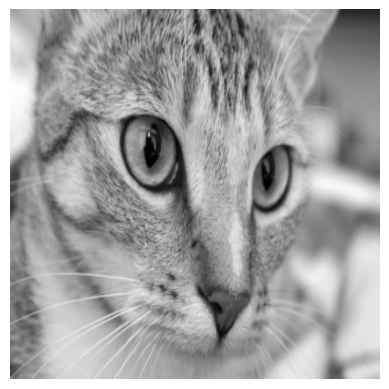

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

# 1. Load the built-in cat image directly from your local Colab files
# This requires ZERO internet downloading!
color_cat = data.chelsea()

# 2. Convert it to grayscale using a standard matrix formula
# (Combining Red, Green, and Blue channels into a single channel)
A_raw = np.dot(color_cat[...,:3], [0.2989, 0.5870, 0.1140])

# 3. Resize it to a perfect 400x400 square matrix
A = transform.resize(A_raw, (400, 400), preserve_range=True).astype(np.uint8)

# 4. Check shape and display the picture
print("Image Matrix Shape:", A.shape)
plt.imshow(A, cmap='gray')
plt.axis('off')
plt.show()

In [5]:
# Perform Singular Value Decomposition using NumPy's linear algebra package (linalg)
U, S, Vt = np.linalg.svd(A, full_matrices=False)

print("Shape of U Matrix:", U.shape)
print("Shape of S Matrix (Singular Values):", S.shape)
print("Shape of Vt Matrix:", Vt.shape)

Shape of U Matrix: (400, 400)
Shape of S Matrix (Singular Values): (400,)
Shape of Vt Matrix: (400, 400)


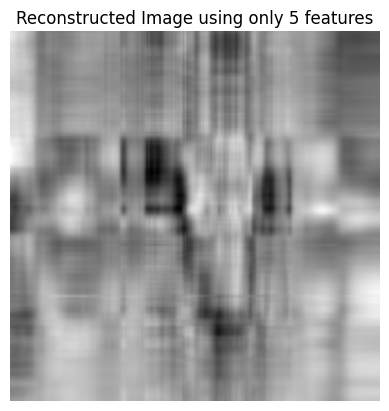

In [6]:
def compress_image(k_features):
    # 1. Take only the top 'k' elements from our matrices
    U_k = U[:, :k_features]
    S_k = np.diag(S[:k_features]) # Turn the list of singular values into a diagonal matrix
    Vt_k = Vt[:k_features, :]

    # 2. Reconstruct the image by multiplying the sliced matrices back together!
    # @ is the symbol for Matrix Multiplication in Python/NumPy
    compressed_A = U_k @ S_k @ Vt_k

    # 3. Display the result
    plt.imshow(compressed_A, cmap='gray')
    plt.title(f"Reconstructed Image using only {k_features} features")
    plt.axis('off')
    plt.show()

# Let's test it out by keeping ONLY 5 features out of 400!
compress_image(5)

Testing different numbers of singular values:


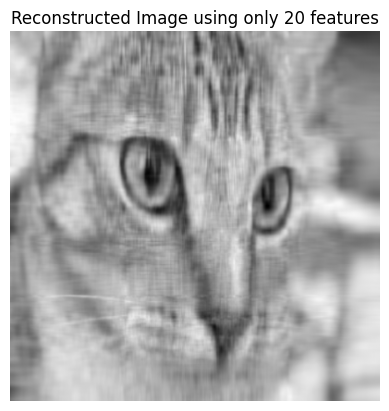

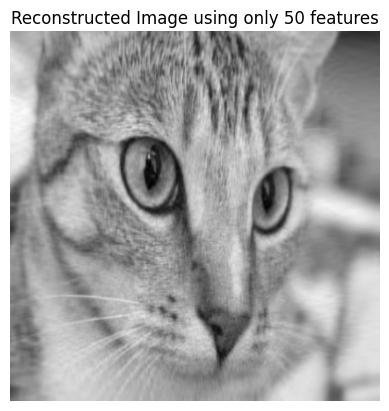

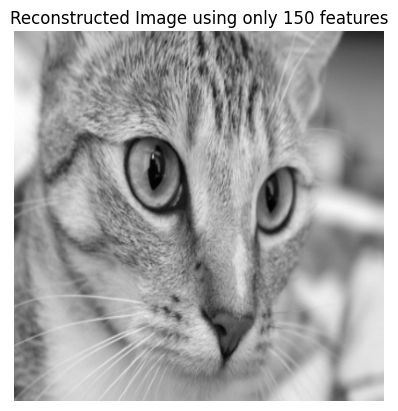

In [7]:
# Test different levels of feature retention
print("Testing different numbers of singular values:")
compress_image(20)   # Keep 20 features
compress_image(50)   # Keep 50 features
compress_image(150)  # Keep 150 features